In [1]:
import numpy as np # linear algebra
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(0)
#from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
import math
def score_dataset(X, y, model=RandomForestRegressor(random_state=1)):
    score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    print(score.mean())
def apply_pca(X, standardize=True):
    # Standardize
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create principal components
    pca = PCA()
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings

In [2]:
rain_file_path = 'data/train2_1.csv'
rain_data = pd.read_csv(rain_file_path)
test_file_path = "data/test.csv"
test_data = pd.read_csv(test_file_path)

In [3]:
test_data.fillna(value=160, inplace=True)
X_test = test_data

In [4]:
rain_data

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,9.3,80.0,26.3,1
1,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1
2,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1
3,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1
4,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1
...,...,...,...,...,...,...,...,...,...,...,...
2551,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1
2552,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1
2553,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1
2554,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1


In [5]:
rain_data["year"] = (rain_data.index + 1) / 365
rain_data["year"] = np.ceil(rain_data.year)
rain_data = rain_data.astype({'year': 'int64'})

In [6]:
rain_data.dtypes

pressure         float64
maxtemp          float64
temparature      float64
mintemp          float64
dewpoint         float64
humidity         float64
cloud            float64
sunshine         float64
winddirection    float64
windspeed        float64
rainfall           int64
year               int64
dtype: object

In [7]:
rain_data.year = rain_data.year.replace(8, 7)

<Axes: xlabel='year', ylabel='mintemp'>

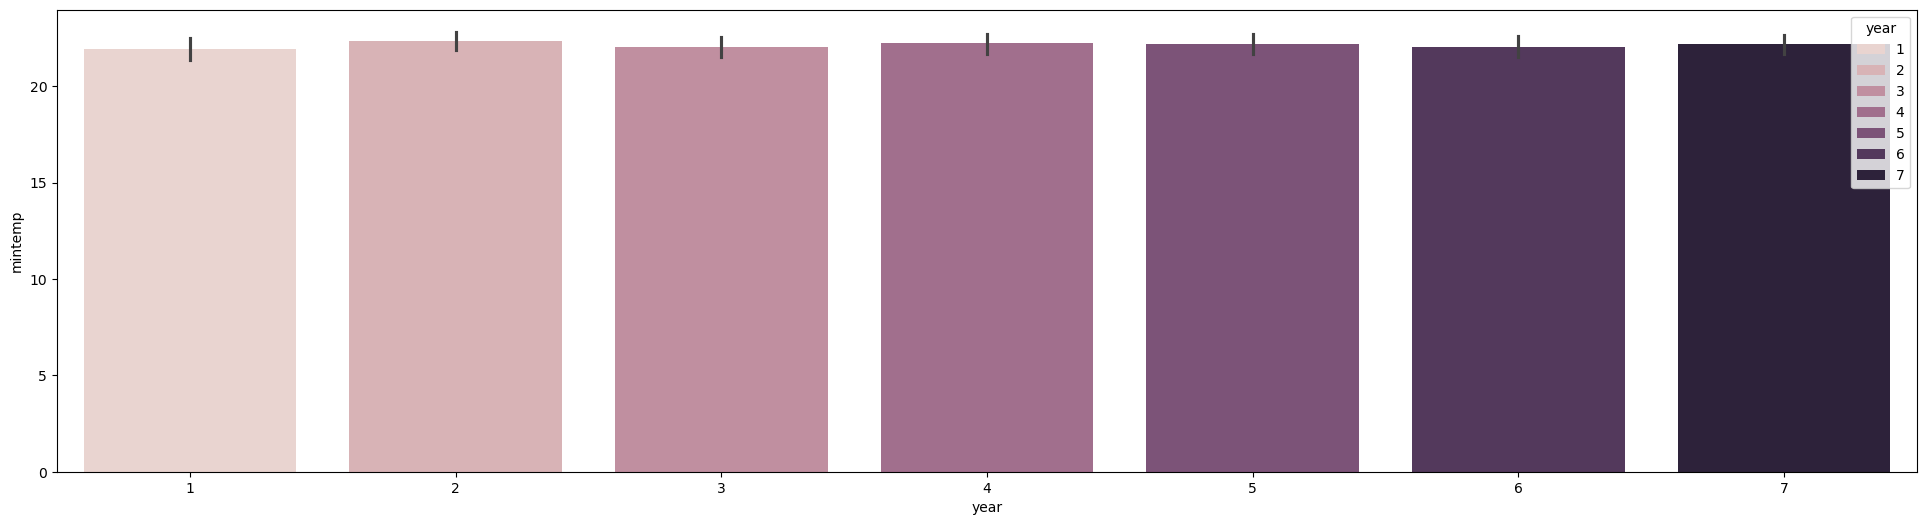

In [8]:
plt.figure(figsize=(24,6))
sns.barplot(y=rain_data.mintemp, x=rain_data.year, hue=rain_data.year)

In [9]:
for a in range(1,8):
    b = rain_data.loc[(rain_data.year == a ) & (rain_data.rainfall == 1)]
    print(b.shape)

(249, 12)
(265, 12)
(275, 12)
(272, 12)
(274, 12)
(276, 12)
(288, 12)


In [10]:
test_data["year"] = (test_data.index + 1) / 365
test_data["year"] = np.ceil(test_data.year)
test_data["year"] = test_data["year"] + 7
test_data = test_data.astype({'year': 'int64'})

In [11]:
rain_data["time"] = np.arange(len(rain_data.index))

In [12]:
rain_data

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,year,time
0,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,9.3,80.0,26.3,1,1,0
1,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1,1,1
2,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1,1,2
3,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1,1,3
4,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2551,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1,7,2551
2552,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1,7,2552
2553,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1,7,2553
2554,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1,7,2554


In [13]:
test_data["time"] = np.arange(len(test_data.index)) + 2556

In [14]:
test_data

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,year,time
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,8,2556
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,8,2557
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,8,2558
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,8,2559
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,8,2560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,2915,361,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,9,3281
726,2916,362,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,9,3282
727,2917,363,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,9,3283
728,2918,364,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,9,3284


In [16]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.232838
sunshine         0.161076
humidity         0.130928
time             0.084347
dewpoint         0.033111
temparature      0.028568
maxtemp          0.026417
mintemp          0.012622
pressure         0.011168
year             0.008852
windspeed        0.004863
winddirection    0.000524
Name: MI Scores, dtype: float64

In [18]:
rain_data['Lag_1'] = rain_data['rainfall'].shift(1)
rain_data.dropna(inplace=True)
rain_data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,year,time,Lag_1
1,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,1,1,1,1.0
2,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,1,1,2,1.0
3,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,1,1,3,1.0
4,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,1,1,4,1.0
5,1018.8,24.3,20.9,19.2,18.0,84.0,51.0,7.7,20.0,14.5,1,1,5,1.0


In [19]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.223735
sunshine         0.171171
humidity         0.144695
time             0.079328
dewpoint         0.034495
temparature      0.032664
mintemp          0.025211
pressure         0.019750
Lag_1            0.019555
maxtemp          0.019153
winddirection    0.012898
year             0.005488
windspeed        0.001694
Name: MI Scores, dtype: float64